# Why unstable betas can still fit returns

SVD separates well-observed combinations of factors from weakly identified directions. A controlled three-factor example compares OLS, ridge, and two-component PCR after a small, deliberately aligned response perturbation. The example explains a mechanism; actual factor conditioning is measured separately.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Goal

Two nearly identical regressors identify their **combined** exposure
much better than their separate coefficients. We construct that
geometry, add a small response perturbation along its weakest direction,
and compare coefficient changes with reconstruction changes.

All observations are constructed. The planted response has zero intercept
and slopes $(0.7,0.7,-0.3)$. Its noise and the later perturbation are
explicitly supplied; neither is estimated from market history.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from research.models import fit_factor_model

FIGURES = ROOT / "research" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(20260920)
n = 120
latent = rng.normal(size=(n, 3))
X = 0.03 * np.column_stack([
    latent[:, 0], latent[:, 0] + 0.001 * latent[:, 1], latent[:, 2]
])
planted_beta = np.array([0.7, 0.7, -0.3])
y = X @ planted_beta + rng.normal(0, 0.003, size=n)
standardized = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)
U, singular, Vt = np.linalg.svd(standardized, full_matrices=False)
display(pd.DataFrame({"Singular value": singular,
                      "Design variance share": singular**2 / np.sum(singular**2)},
                     index=["Direction 1", "Direction 2", "Direction 3"]))

,Singular value,Design variance share
Direction 1,15.499572,6.673243e-01
Direction 2,10.943637,3.326756e-01
Direction 3,0.008343,1.933554e-07


### 1. Three ways to treat the same singular directions

OLS uses every numerically identified direction. Ridge solves
$\|y_c-Z\gamma\|^2/n+\lambda\|\gamma\|^2$, with
$\lambda=0.1$ and unpenalized intercept. Its fitted-response filter
is $s_j^2/(s_j^2+n\lambda)$. PCR keeps two directions and gives
the third a zero filter. Centering and scaling use only this fitting
sample; output slopes are returned to the original factor units.

In [3]:
options = {"OLS": {"method": "ols"},
           "Ridge": {"method": "ridge", "ridge_lambda": 0.1},
           "PCR (2)": {"method": "pcr", "n_components": 2}}
fits = {name: fit_factor_model(X, y, **kwargs) for name, kwargs in options.items()}
coefficient_table = pd.DataFrame(
    {name: fit.beta for name, fit in fits.items()}, index=["Factor 1", "Factor 2", "Factor 3"]
)
coefficient_table["Planted slope"] = planted_beta
display(coefficient_table.round(6))
display(pd.DataFrame({name: {"Condition number": fit.standardized_condition,
                                   "Effective df including intercept": fit.effective_df}
                      for name, fit in fits.items()}).T.round(4))

,OLS,Ridge,PCR (2),Planted slope
Factor 1,16.876192,0.667462,0.701175,0.7
Factor 2,-15.474364,0.667338,0.701244,0.7
Factor 3,-0.293140,-0.262586,-0.291007,-0.3


,Condition number,Effective df including intercept
OLS,1857.7628,4.0000
Ridge,1857.7628,2.8614
PCR (2),1857.7628,3.0000


### 2. Inspect the filters before interpreting the coefficients

The small singular value measures weak support for one combination of
named factors. Its squared value, not its value alone, determines its
share of design variance. Dropping a low-variance direction may remove
useful response information; explained variance is not predictive merit.

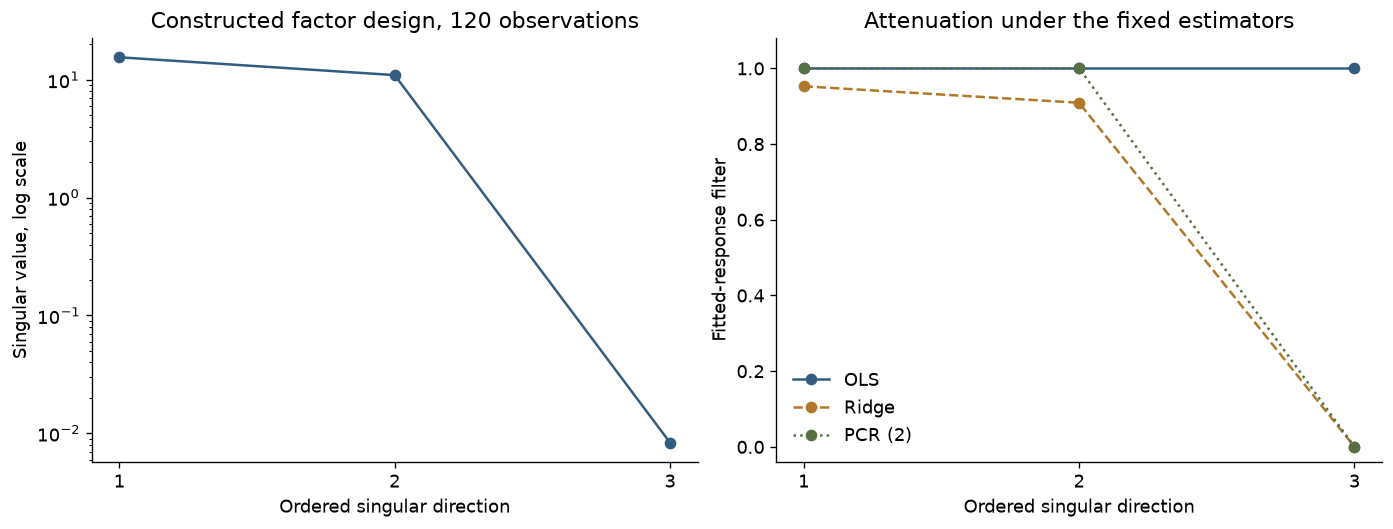

In [4]:
palette = {"OLS": "#335C81", "Ridge": "#B07828", "PCR (2)": "#567044"}
positions = np.arange(1, 4)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), layout="constrained")
axes[0].semilogy(positions, singular, "o-", color="#335C81")
axes[0].set(xticks=positions, xlabel="Ordered singular direction",
            ylabel="Singular value, log scale", title="Constructed factor design, 120 observations")
for name, fit in fits.items():
    axes[1].plot(positions, fit.shrink_filters, marker="o", color=palette[name], label=name,
                 linestyle={"OLS": "-", "Ridge": "--", "PCR (2)": ":"}[name])
axes[1].set(xticks=positions, xlabel="Ordered singular direction",
            ylabel="Fitted-response filter", ylim=(-0.04, 1.08), title="Attenuation under the fixed estimators")
axes[1].legend(frameon=False, loc="lower left")
fig.savefig(FIGURES / "topic_svd_filters.png", dpi=160, bbox_inches="tight")
plt.show()

### 3. Add a known perturbation and keep the comparison paired

The response perturbation has RMS **0.5 basis points** and is
deliberately aligned with the smallest left singular vector. This is
a sensitivity construction, not a typical-noise claim. Independently
generated probe factors either preserve the original near-collinearity
or increase the difference between factors 1 and 2. Probe results measure
changes caused by the perturbation, not total forecast error.

,"Slope change, L2",Same-geometry RMS change (bps),Changed-geometry RMS change (bps)
Estimator,,,
OLS,2.267197,0.512720,152.837493
Ridge,0.000013,0.000003,0.000887
PCR (2),0.000000,0.000000,0.000000


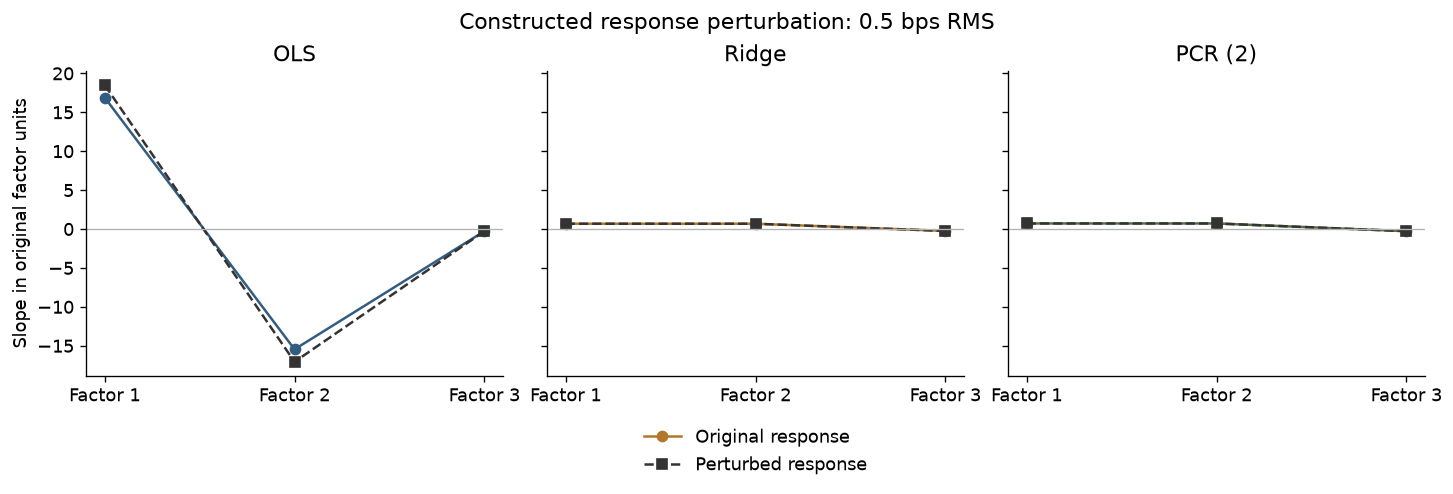

In [5]:
perturbation = 0.00005 * np.sqrt(n) * U[:, -1]
altered = {name: fit_factor_model(X, y + perturbation, **kwargs)
           for name, kwargs in options.items()}
probe_latent = rng.normal(size=(300, 3))
probe = 0.03 * np.column_stack([
    probe_latent[:, 0], probe_latent[:, 0] + 0.001 * probe_latent[:, 1], probe_latent[:, 2]
])
changed_geometry = 0.03 * np.column_stack([
    probe_latent[:, 0], probe_latent[:, 0] + 0.3 * probe_latent[:, 1], probe_latent[:, 2]
])
rows = []
for name, fit in fits.items():
    changed = altered[name]
    rows.append({"Estimator": name,
                 "Slope change, L2": np.linalg.norm(changed.beta - fit.beta),
                 "Same-geometry RMS change (bps)": np.sqrt(np.mean((changed.predict(probe) - fit.predict(probe))**2)) * 10000,
                 "Changed-geometry RMS change (bps)": np.sqrt(np.mean((changed.predict(changed_geometry) - fit.predict(changed_geometry))**2)) * 10000})
stability = pd.DataFrame(rows).set_index("Estimator")
display(stability.round(6))
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, layout="constrained")
for ax, (name, fit) in zip(axes, fits.items()):
    ax.plot(positions, fit.beta, "o-", color=palette[name], label="Original response")
    ax.plot(positions, altered[name].beta, "s--", color="0.2", label="Perturbed response")
    ax.axhline(0, color="0.7", linewidth=0.8)
    ax.set(title=name, xticks=positions, xticklabels=["Factor 1", "Factor 2", "Factor 3"])
axes[0].set_ylabel("Slope in original factor units")
axes[1].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.suptitle("Constructed response perturbation: 0.5 bps RMS")
fig.savefig(FIGURES / "topic_svd_stability.png", dpi=160, bbox_inches="tight")
plt.show()

### 4. Verify the algebra along an independent path

A direct least-squares solve supplies an OLS check. A direct penalized
normal-equation solve checks ridge on this controlled design. The latter
is a validation identity, not a recommendation to form normal equations
for ill-conditioned unregularized production regressions.

In [6]:
direct_ols = np.linalg.lstsq(np.column_stack([np.ones(n), X]), y, rcond=None)[0]
np.testing.assert_allclose(np.r_[fits["OLS"].intercept, fits["OLS"].beta],
                           direct_ols, atol=1e-8)
direct_ridge = np.linalg.solve(
    standardized.T @ standardized + n * 0.1 * np.eye(3),
    standardized.T @ (y - y.mean()),
)
np.testing.assert_allclose(fits["Ridge"].beta, direct_ridge / X.std(axis=0), atol=1e-10)
np.testing.assert_allclose(np.sqrt(np.mean(perturbation**2)), 0.00005, atol=1e-15)
np.testing.assert_allclose(fits["Ridge"].shrink_filters,
                           singular**2 / (singular**2 + n * 0.1), atol=1e-12)
display(Markdown(
    f"**Result:** the constructed standardized condition number is "
    f"**{fits['OLS'].standardized_condition:,.0f}**. The paired OLS slope change "
    f"has L2 norm **{stability.loc['OLS', 'Slope change, L2']:.3f}**, while its "
    f"same-geometry reconstruction changes by **{stability.loc['OLS', 'Same-geometry RMS change (bps)']:.3f} bps RMS**. "
    "The changed-geometry probe shows why stable fitted values on one design "
    "do not guarantee stable attribution when factor relationships change."
))

**Result:** the constructed standardized condition number is **1,858**. The paired OLS slope change has L2 norm **2.267**, while its same-geometry reconstruction changes by **0.513 bps RMS**. The changed-geometry probe shows why stable fitted values on one design do not guarantee stable attribution when factor relationships change.

## Takeaway

SVD explains where the sensitivity comes from. Ridge and PCR trade that
sensitivity for bias; neither creates additional economic information.
Using SVD to solve ordinary least squares does not itself regularize the
model. The empirical study must measure actual conditioning and compare
reconstruction losses before drawing a conclusion about sector ETFs.

Continue to [alpha and uncertainty](../03-alpha-uncertainty/study.ipynb),
or read the [empirical protocol](../../research/PROTOCOL.md).